# Imports

## General imports

In [3]:
import os
from matplotlib import pyplot as plt
import numpy as np
import pickle
from importlib import reload
import time
import copy

## Specialized imports

In [4]:
from common.baseclasses import AWA # https://github.com/asmcleod/common.git
from common.misc import flatten
from common import numerical_recipes as numrec
from NearFieldOptics import Materials as M # https://github.com/asmcleod/NearFieldOptics.git
from NearFieldOptics.Materials import material_types,TransferMatrixMedia
# from mnOPSuite.PRISM.python import scandelay_FTIR as sd # https://github.com/mnop-laboratory/mnOPSuite.git

<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Bi2Se3_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "PMMA_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "sio2_300nm_extracted_epsilon_cone_A=2a.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_230K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_30K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Erik_BSTS_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_295K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_360K.csv"...
<material_types.Ta

## Tools for inversion

In [5]:
import ProbeCavityEigenfields as PCE # https://github.com/asmcleod/ProbeCavityEigenfields.git
from ProbeCavityEigenfields import RotationalMoM as RotMOM
from ProbeCavityEigenfields import ProbeSpectroscopy as PS
from ProbeCavityEigenfields import EigenInversion as EI 

<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "BlueRed" and "BlueRed_r"...
<plotting>:
	Registered colormaps "vanheum3" and "vanheum3_r"...
<plotting>:
	Registered colormaps "vanheum2" and "vanheum2_r"...


# Initialize simulation parameters

In [6]:
sim_kwargs=dict(a_nm=10,
                gapmin_nm=1,
                amplitude_nm=50,
                Ngaps=96/2,
               Nmodes=20) # We can change these later as we like

# Load Probe and build/load its tools for simulation

## Load probe

Attemping to load from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	Registering probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!


(-2e-06, 1.4e-05)

<Figure size 640x480 with 0 Axes>

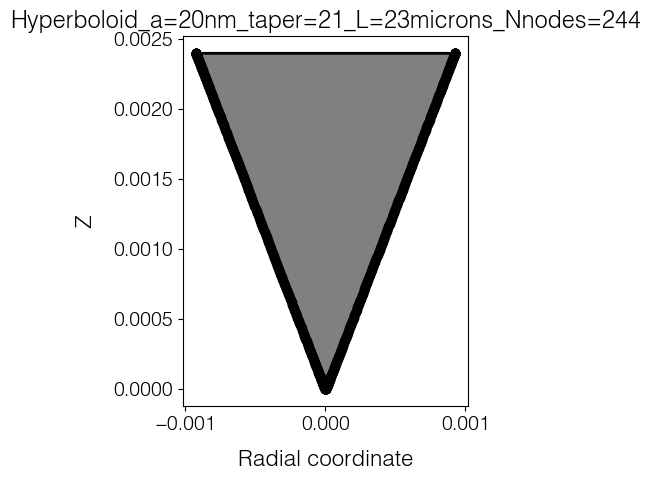

<Figure size 640x480 with 0 Axes>

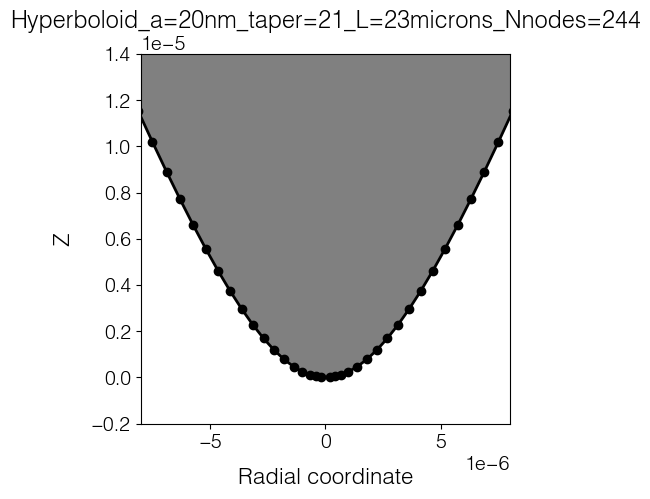

In [7]:
# Pickle files associated with probe "Hyperboloid=20nm_L=23microns_Nnodes=488" or "hyperboloid" should be distributed with this notebook
# But other probes can be used or generated.
# Take the files labeled 'hyperboloid' and place in `ProbeCavityEigenfields/Probe models`

# The probes that works best have their ProbeGapSpectroscopy with a basis gap of ~tip radius
#probe_name = 'Cone_a=20nm_taper=21_L=23microns_Nnodes=244'  
probe_name = 'Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244'  
#probe_name = 'Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488' # Slow

Probe=P=PCE.load(probe_name,PCE.Probe)
a = Probe.get_a()

plt.figure()
P.plot_geometry()

plt.figure()
P.plot_geometry()
window=8
plt.xlim(-window/2*a,+window/2*a)
plt.ylim(-a,(window-1)*a)


## Load / recompute ProbeGapSpectroscopy

Attemping to load from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_ProbeGapSpectroscopy.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244" is already instantiated!  If you wish to overwrite this probe, remove it from the collection of probes by using the `del` command!
You may avert this error by passing keyword `overwrite=True` to `load`!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244

Text(0.5, 1.0, 'Eigenmode Brightness from ProbeGapSpectroscopy')

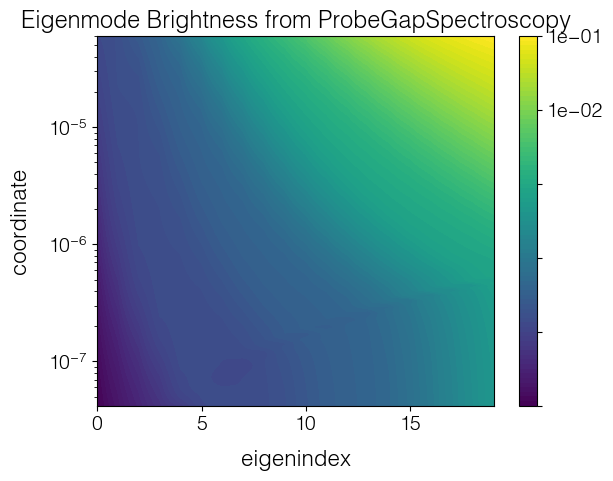

In [8]:
#-- Build/load Probe gap spectroscopy

recompute=False
overwrite=False

try:
    if recompute: raise OSError
    ProbeGapSpectroscopy = PCE.load(probe_name,PS.ProbeGapSpectroscopyParallel)
except OSError:
    print('Recomputing Probe Gap Spectroscopy...')

    a=P.get_a()
    gap0 = a/5 # This is key.  Unless Nmodes is large, and unless basis gap has high spatial frequency content, we can't adequately describe SiC.
    gapmin=a/100; gapmax=a*50
    gaps,_=numrec.GetQuadrature(xmin=gapmin,xmax=gapmax*2,N=144*2,quadrature=numrec.TS)
    gaps=gaps[:len(gaps)//2] # Take bottom half of quadrature points; the top half is very dense at large values which is useless
    
    ProbeGapSpectroscopy = PS.ProbeGapSpectroscopyParallel(Probe, gaps=gaps, \
                                                         ncpus=8, backend='multiprocessing', \
                                                         Nmodes=50, sommerfeld=False,
                                                         basis_gap=gap0,
                                                         reversed=False)  
        
    print('Min gapsize/a in spectroscopy:',ProbeGapSpectroscopy.get_coords().min()/P.get_a())
    print('Max gapsize/a in spectroscopy:',ProbeGapSpectroscopy.get_coords().max()/P.get_a())
    print('N gaps in spectroscpy:',len(ProbeGapSpectroscopy.get_coords()))
    
    save_gapspectroscopy=False
    overwrite_gapspectroscopy=True
    
    #--- Classify eigenfields and find range of good modes
    Nmodes_classify=sim_kwargs['Nmodes']
    ProbeGapSpectroscopy(Nmodes=Nmodes_classify,reversed=False,by_rho=True,debug=False,coordmax=10*P.get_a())
    eigenrhos = ProbeGapSpectroscopy.get_eigenrhos_AWA()
    eigencharges = ProbeGapSpectroscopy.get_eigencharges_AWA()
    ProbeGapSpectroscopy.plot_eigenrhos(Nmodes=Nmodes_classify)
    
    try: PCE.save(ProbeGapSpectroscopy,overwrite=overwrite_gapspectroscopy)
    except OSError: pass

#--- Plot brightness, how many modes are good?
angles=np.linspace(10,90,20)
all_vs = ProbeGapSpectroscopy.get_eigenbrightness_AWA(angles=angles,verbose=True)
plt.figure()
np.abs(all_vs).plot(plotter=plt.contourf,log_scale=True)
plt.gca().set_yscale('log')
plt.title('Eigenmode Brightness from ProbeGapSpectroscopy')

## Load / recompute EncodedEigenfields

In [9]:
#-- Build/load encoded eigenfields

recompute=False
overwrite=False

try:
    if recompute: raise OSError
    EE = PCE.load(probe_name,PS.EncodedEigenfields)
except OSError:
    print('Recomputing Encoded Eigenfields...')
    gap0 = P.get_a()/5 # This is key.  Unless Nmodes is large, and unless basis gap has high spatial frequency content, we can't adequately describe SiC.
    EE = PS.EncodedEigenfields(ProbeGapSpectroscopy,gap0=gap0, Nmodes=sim_kwargs['Nmodes'],
                                kappa_min=None, kappa_max=10/P.get_a(),
                                Nkappas=244*4, qquadrature=PCE.numrec.GL)
    try: PCE.save(EE,overwrite=overwrite)
    except OSError: pass

Attemping to load from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_EncodedEigenfields.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244" is already instantiated!  If you wish to overwrite this probe, remove it from the collection of probes by using the `del` command!
You may avert this error by passing keyword `overwrite=True` to `load`!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_

## Load / recompute InvertibleEigenfields

In [51]:
#-- Build invertible eigenfields

recompute=True
overwrite=True

try:
    if recompute: raise OSError
    IE = PCE.load(probe_name,PS.InvertibleEigenfields)
except OSError:
    print('Recomputing Invertible Eigenfields...')
    IE = PS.InvertibleEigenfields(ProbeGapSpectroscopy, Nmodes=sim_kwargs['Nmodes'],
                                interpolation='quadratic',bounds_error=True)
    try: PCE.save(IE,overwrite=overwrite)
    except OSError: pass

Recomputing Invertible Eigenfields...
Successfully saved to file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_InvertibleEigenfields.pickle"!


## Compare simulation methods

For modestly demanding simulations, ensure they all converge to the same result

In [11]:
sim_kwargs

{'a_nm': 10, 'gapmin_nm': 1, 'amplitude_nm': 50, 'Ngaps': 48.0, 'Nmodes': 20}

amplitude= 9.999999999999999e-06
gapmin= 2e-07
<ProbeCavityEigenfields.Probe.get_eigenbrightness>:
	Computing eigenbrightness at k=6283.19...
<ProbeCavityEigenfields.Probe.EradVsGap>:
	Computing response for 48 gaps at freq=750.0970568971655...
<ProbeCavityEigenfields.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<ProbeCavityEigenfields.Probe.EradVsGap>:
	Computing response for 48 gaps at freq=758.7188621488572...
<ProbeCavityEigenfields.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<ProbeCavityEigenfields.Probe.EradVsGap>:
	Computing response for 48 gaps at freq=767.3406674005487...
<ProbeCavityEigenfields.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<ProbeCavityEigenfields.Probe.EradVsGap>:
	Computing response for 48 gaps at freq=775.9624726522402...
<ProbeCavityEigenfie

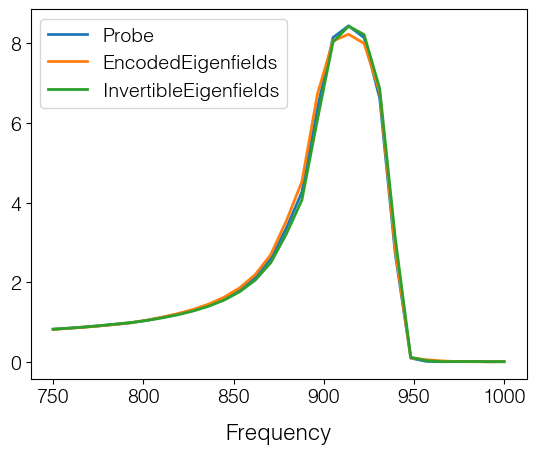

In [12]:
do_compare=False

if do_compare:

    freqs=np.linspace(750,1000,30)
    material=M.SiC_6H
    #material=M.SiO2_300nm
    #material=M.PMMA
    beta = material.reflection_p(freqs,q=1/30e-7)

    T=PCE.Timer()
    signals = P.getNormalizedSignal(freqs,rp=material.reflection_p,rp_norm=M.Au.reflection_p,
                                    Nkappas=244,kappa_max=10/P.get_a(),**sim_kwargs)
    np.abs(signals['Sn_norm'][3]).plot(label='Probe')
    print('---- Probe calculator: ----')
    print(T())
    print()
    
    
    T=PCE.Timer()
    signals_EE = EE.getNormalizedSignal(freqs,rp=material.reflection_p,rp_norm=M.Au.reflection_p,
                                    **sim_kwargs)
    np.abs(signals_EE['Sn_norm'][3]).plot(label='EncodedEigenfields')
    print('---- EncodedEigenfields calculator: ----')
    print(T())
    print()

    T=PCE.Timer()
    #Shockingly, as few modes as 10 still accurately reproduce the data
    IE_kwargs = copy.copy(sim_kwargs)
    IE_kwargs['Nmodes']=10
    
    signals_IE = IE.getNormalizedSignal(beta=beta,beta_norm=[1]*len(beta),
                                    **IE_kwargs)
    np.abs(signals_IE['Sn_norm'][3]).plot(label='InvertibleEigenfields')
    print('---- InvertibleEigenfields calculator: ----')
    print(T())
    print()
    
    plt.legend()

It should now be clear that we can use `InvertibleEigenfields` to make accurate predictions in all cases where dipsersion can be negletcted in the reflection coefficient (e.g. for bulk media, like half-spaces of silicon or gold).

# Calculate the s-SNOM approach curve over a SiC surface

In [36]:
gaps_nm

array([6.28912565e-01, 6.33875917e-01, 6.39234351e-01, 6.45015726e-01,
       6.51249586e-01, 6.57967242e-01, 6.65201859e-01, 6.72988542e-01,
       6.81364430e-01, 6.90368789e-01, 7.00043107e-01, 7.10431198e-01,
       7.21579301e-01, 7.33536190e-01, 7.46353280e-01, 7.60084743e-01,
       7.74787619e-01, 7.90521937e-01, 8.07350836e-01, 8.25340689e-01,
       8.44561233e-01, 8.65085695e-01, 8.86990930e-01, 9.10357557e-01,
       9.35270095e-01, 9.61817108e-01, 9.90091354e-01, 1.02018992e+00,
       1.05221441e+00, 1.08627102e+00, 1.12247080e+00, 1.16092973e+00,
       1.20176892e+00, 1.24511475e+00, 1.29109906e+00, 1.33985933e+00,
       1.39153880e+00, 1.44628669e+00, 1.50425836e+00, 1.56561547e+00,
       1.63052619e+00, 1.69916537e+00, 1.77171471e+00, 1.84836295e+00,
       1.92930606e+00, 2.01474742e+00, 2.10489801e+00, 2.19997660e+00,
       2.30020994e+00, 2.40583294e+00, 2.51708886e+00, 2.63422952e+00,
       2.75751547e+00, 2.88721617e+00, 3.02361023e+00, 3.16698552e+00,
      

In [80]:

IE_kwargs=copy.copy(sim_kwargs)
IE_kwargs['a_nm']=50
IE_kwargs['amplitude_nm']=IE_kwargs['a_nm']

# Identify the maximum probe-sample gap amplitude, above which we cannot make reliable predictions
gaps_nm = IE.Rs.axes[0]/Probe.get_a() * IE_kwargs['a_nm']
#gapmin_max_nm = gaps_nm.max()-2*IE_kwargs['amplitude_nm'] # don't go higher that this, or else we query the probe-sample response above where it is predicted
gapmin_max_nm=200
gapmins_calc=np.linspace(gaps_nm.min(),gapmin_max_nm,200)
print('Maximum value of gapmin (nm):',gapmin_max_nm)

freqs=np.linspace(850,1000,200)
material=M.SiC_6H
beta = material.reflection_p(freqs,q=1/30e-7)

s3_spectra = []
for gapmin_nm in gapmins_calc:
    IE_kwargs['gapmin_nm']=gapmin_nm
    signals_IE = IE.getNormalizedSignal(beta=beta,beta_norm=None,
                                        **IE_kwargs)
    s3_spectra.append( signals_IE['Sn'][3] )

Maximum value of gapmin (nm): 200
amplitude= 2e-06
gapmin= 4.1927504356541e-08
amplitude= 2e-06
gapmin= 8.191781840500059e-08
amplitude= 2e-06
gapmin= 1.2190813245346018e-07
amplitude= 2e-06
gapmin= 1.618984465019198e-07
amplitude= 2e-06
gapmin= 2.0188876055037937e-07
amplitude= 2e-06
gapmin= 2.41879074598839e-07
amplitude= 2e-06
gapmin= 2.8186938864729853e-07
amplitude= 2e-06
gapmin= 3.2185970269575813e-07
amplitude= 2e-06
gapmin= 3.618500167442177e-07
amplitude= 2e-06
gapmin= 4.018403307926773e-07
amplitude= 2e-06
gapmin= 4.4183064484113684e-07
amplitude= 2e-06
gapmin= 4.818209588895964e-07
amplitude= 2e-06
gapmin= 5.218112729380561e-07
amplitude= 2e-06
gapmin= 5.618015869865157e-07
amplitude= 2e-06
gapmin= 6.017919010349753e-07
amplitude= 2e-06
gapmin= 6.417822150834349e-07
amplitude= 2e-06
gapmin= 6.817725291318945e-07
amplitude= 2e-06
gapmin= 7.217628431803542e-07
amplitude= 2e-06
gapmin= 7.617531572288136e-07
amplitude= 2e-06
gapmin= 8.017434712772733e-07
amplitude= 2e-06
gapmin=

(850.0, 950.0)

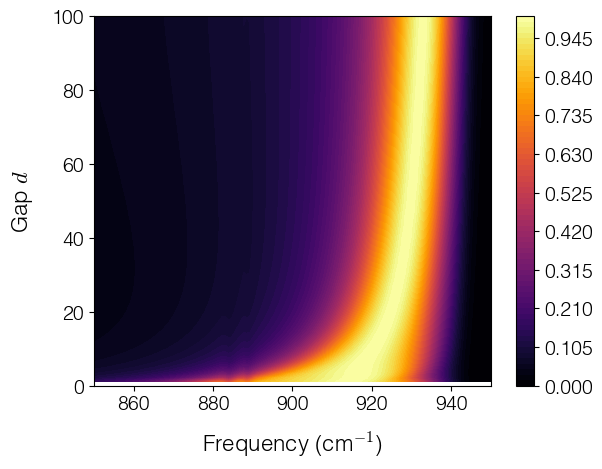

In [81]:
s3_spectra=AWA(s3_spectra,axes=[gapmins_calc,freqs],axis_names=['Gap $d$','Frequency (cm$^{-1}$)'])
s3_maxes = np.abs(s3_spectra).max(axis=1)[:,np.newaxis]
np.abs(s3_spectra/s3_maxes).T.plot(plotter=plt.contourf,cmap='inferno')
#plt.gca().set_yscale('log')
plt.ylim(0,100)
plt.xlim(850,950)

# Calculate total scattered field from probe versus distance

Text(0.5, 1.0, 'Radiated field')

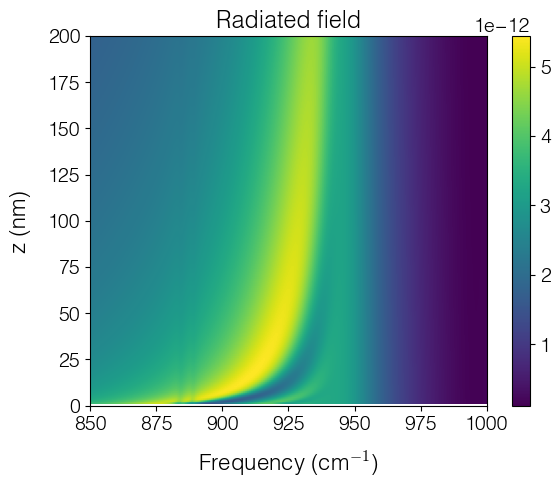

In [83]:
zs_a_units = gapmins_calc/IE_kwargs['a_nm']*P.get_a()
Erad = IE.get_Erad(beta, zs=zs_a_units)
Erad.set_axes([None,gapmins_calc],axis_names=['Frequency (cm$^{-1}$)','z (nm)'])

np.abs(Erad).plot()
plt.ylim(0,200)

plt.title('Radiated field')

In [84]:
nodes = IE.get_demodulation_nodes

Signature: IE.get_Erad_from_nodes(beta, nodes, Nmodes=None)
Docstring: <no docstring>
File:      ~/tools/python/ProbeCavityEigenfields/ProbeSpectroscopy.py
Type:      method

In [91]:
a=P.get_a()
harms = [1,2,3,4]
for n in harms:
    nodes = IE.get_demodulation_nodes(zmin=.01*a,amplitude=4*a,harmonic=n)
    s = np.sum(IE.get_Erad_from_nodes(beta=1,nodes=nodes))*1e14
    print(s)

(11.132537494441952+61.14212059168162j)
(-5.238698576027768-19.181824185140822j)
(5.549776799095133+9.34350461270977j)
(-5.847664599071012-5.63525695494403j)


# Test

In [54]:
betas = np.linspace(-5,5,100)
amps=np.linspace(.1,10,100)
harmonics=(1,2,3)
Nts=100
Ssss=[]
for harmonic in harmonics:
    Sss=[]
    for amp in amps:
        nodes = IE.get_demodulation_nodes(zmin=.03*a,amplitude=amp*a,harmonic=harmonic,Nts=Nts)
        Ss = []
        for beta in betas:
            s = np.sum(IE.get_Erad_from_nodes(beta=beta*(1+.1j),nodes=nodes))
            Ss.append(s)
        Sss.append(Ss)
    Ssss.append(Sss)

S = AWA(Ssss,axes=[harmonics,amps,betas],axis_names=['harmonic','amplitude','beta'])

Text(0.5, 1.0, 'S3/S2')

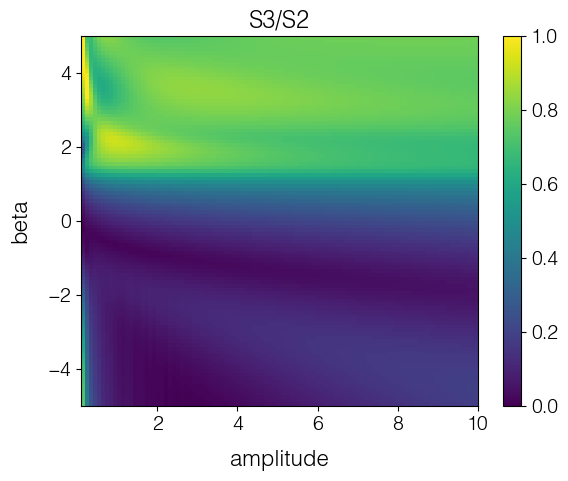

In [55]:
np.abs(S.cslice[3]/S.cslice[2]).plot()
plt.clim(0,1)
plt.title('S3/S2')

In [92]:
IE.Rs.shape

(245, 20)

In [95]:
Q=2
IE.slender_factor=1#*np.exp(-1j*1/Q)
IE.verbose=False
Nmodes=10

betas_r = np.linspace(-10,10,100)
betas_i = np.linspace(0,20,100)
amp=4
harmonics=(1,2,3,4,5)
Nts=100
Ssss=[]
for harmonic in harmonics:
    nodes = IE.get_demodulation_nodes(zmin=.03*a,amplitude=amp*a,harmonic=harmonic,Nts=Nts)
    Sss=[]
    for beta_r in betas_r:
        Ss = []
        for beta_i in betas_i:
            beta = beta_r+1j*beta_i
            s = np.sum(IE.get_Erad_from_nodes(beta=beta,nodes=nodes,Nmodes=Nmodes))
            Ss.append(s)
        Sss.append(Ss)
    Ssss.append(Sss)

S = AWA(Ssss,axes=[harmonics,betas_r,betas_i],axis_names=['harmonic',r'Re $\beta$',r'Im $\beta$'])

Text(0.5, 1.0, 'S3/S2')

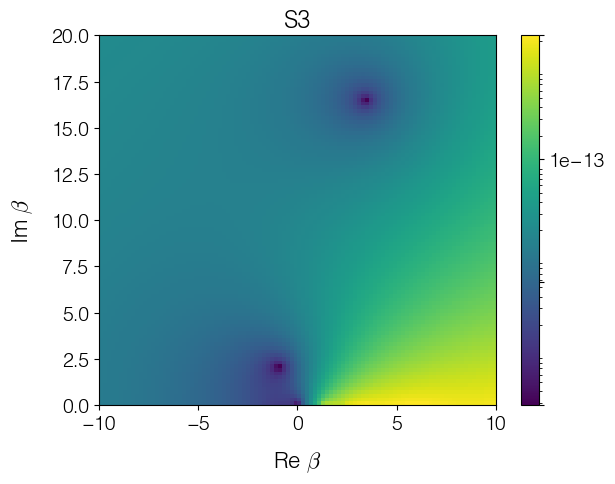

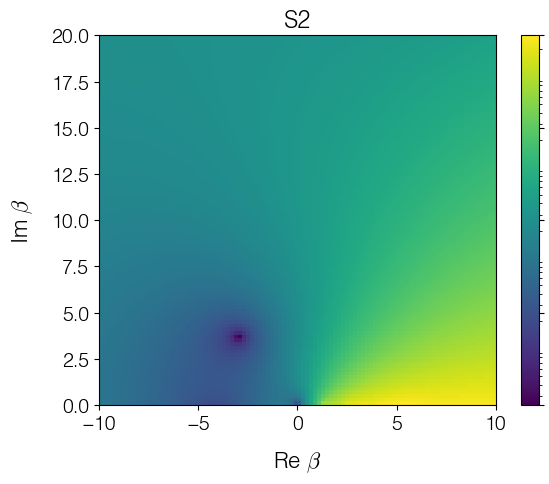

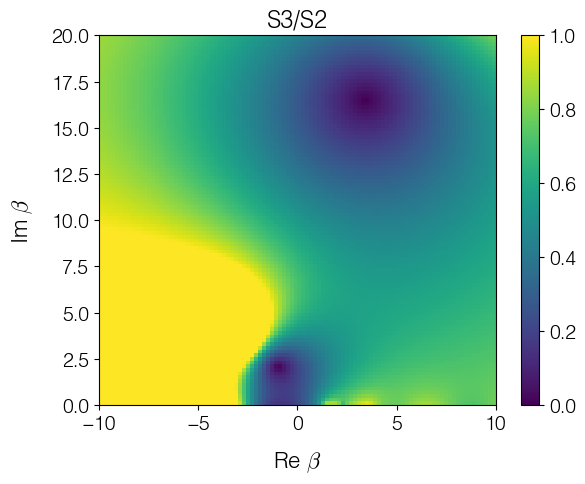

In [96]:
plt.figure()
np.abs(S.cslice[3]).plot(log_scale=True)
#plt.clim(0,1)
plt.title('S3')

plt.figure()
np.abs(S.cslice[2]).plot(log_scale=True)
#plt.clim(0,1)
plt.title('S2')

plt.figure()
np.abs(S.cslice[3]/S.cslice[2]).plot()
plt.clim(0,1)
plt.title('S3/S2')

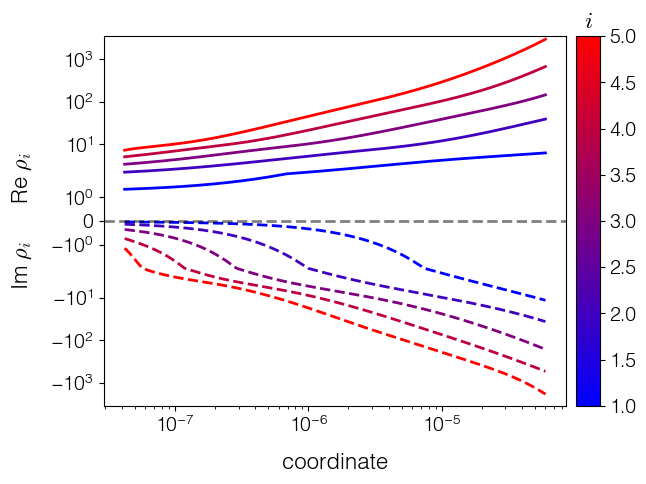

In [101]:
ProbeGapSpectroscopy.plot_eigenrhos(Nmodes=5)

In [109]:
eigenrhos = ProbeGapSpectroscopy.get_eigenrhos_AWA().copy()
eigenrhos.set_axes([None,eigenrhos.axes[1]/P.get_a()])

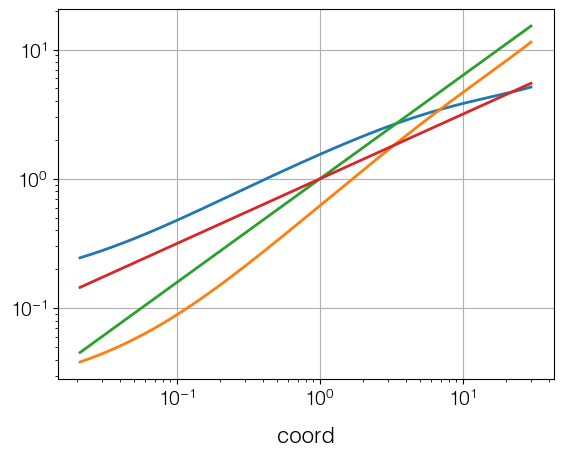

In [134]:
(eigenrhos[0].real-1.1).plot(plotter=plt.loglog)
(-eigenrhos[0].imag).plot(plotter=plt.loglog)
zs = eigenrhos[0].axes[0]
plt.grid()
plt.plot(zs,zs**0.8)
plt.plot(zs,zs**0.5)

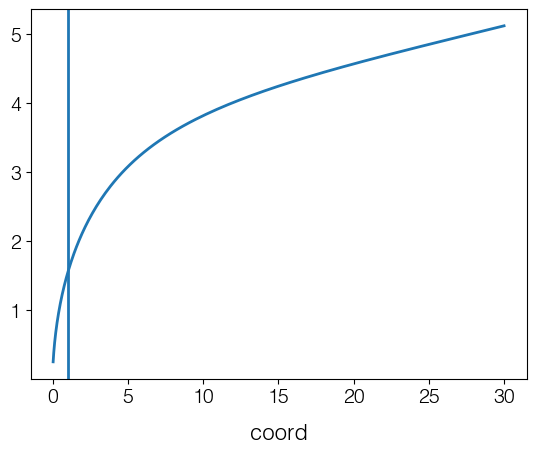

In [136]:
(eigenrhos[0].real-1.1).plot()
plt.axvline(1)

In [139]:
M.Au.reflection_p(1000,angle=60)

(0.9940392080596634+0.05784266739107041j)

In [140]:
M.Si.reflection_p(1000,angle=60)

(0.2774210964790282+2.517716994580061e-08j)